In [1]:
# =============================================================================
# EJERCICIOS PRÁCTICOS: CURVAS ROC Y AUC
#=============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score

# =============================================================================
# EJERCICIO 1: Cálculo Manual de Métricas
# =============================================================================
print("=" * 70)
print("EJERCICIO 1: Cálculo Manual de Métricas")
print("=" * 70)

# Supón que un modelo de diagnóstico médico ha evaluado a 100 pacientes:
vp = 45  # Verdaderos Positivos
fn = 5   # Falsos Negativos
fp = 10  # Falsos Positivos
vn = 40  # Verdaderos Negativos

# 1. Calcula el TPR (Sensibilidad)
# Fórmula: TPR = VP / (VP + FN)
tpr = vp / (vp + fn)

# 2. Calcula el FPR (Falsa Alarma)
# Fórmula: FPR = FP / (FP + VN)
fpr = fp / (fp + vn)

print(f"Sensibilidad (TPR) calculada: {tpr:.2f} (Esperado: 0.90)")
print(f"Tasa de Falsa Alarma (FPR) calculada: {fpr:.2f} (Esperado: 0.20)\n")




EJERCICIO 1: Cálculo Manual de Métricas
Sensibilidad (TPR) calculada: 0.90 (Esperado: 0.90)
Tasa de Falsa Alarma (FPR) calculada: 0.20 (Esperado: 0.20)



In [3]:
# =============================================================================
# EJERCICIO 2: Entrenamiento y Extracción de Probabilidades
# =============================================================================
print("=" * 70)
print("EJERCICIO 2: Entrenamiento del Modelo y Regla de Oro")
print("=" * 70)

# CONFIGURACIÓN PARA USAR TU PROPIO ARCHIVO CSV:
# 1. Cambia 'USAR_CSV' a True cuando quieras usar tus datos reales.
# 2. Sube tu archivo a tu entorno de Colab/directorio de trabajo.
# 3. Define el nombre de tu archivo y tu columna objetivo (clase 0 o 1).

USAR_CSV = False  # <<< ¡Cambia a True para cargar tu archivo CSV!
RUTA_CSV = "tu_archivo.csv"  # <-- Nombre de tu archivo .csv
COLUMNA_OBJETIVO = "target"   # <-- Nombre de la columna con las etiquetas (0 y 1)

if USAR_CSV:
    print(f"Cargando tus datos reales desde: {RUTA_CSV}...")
    try:
        # Carga del dataset mediante pandas
        df_custom = pd.read_csv(RUTA_CSV)

        # Limpieza rápida: eliminamos valores nulos si los hubiera
        df_custom = df_custom.dropna()

        # Separación en Variables Predictoras (X) y Variable Objetivo (y)
        X = df_custom.drop(columns=[COLUMNA_OBJETIVO]).values
        y = df_custom[COLUMNA_OBJETIVO].values

        print(f"CSV cargado correctamente. Registros: {len(X)} | Características: {X.shape[1]}")
    except Exception as e:
        print(f"Error al cargar el archivo CSV: {e}")
        print("Cargando dataset sintético de respaldo por defecto...")
        X, y = make_classification(n_samples=1000, n_features=8, weights=[0.7, 0.3], random_state=42)
else:
    # Generamos un dataset sintético de prueba por defecto (70% clase 0, 30% clase 1)
    X, y = make_classification(
        n_samples=1000,
        n_features=8,
        weights=[0.7, 0.3],
        random_state=42
    )
    print("Usando dataset sintético de prueba (para usar tu CSV, cambia 'USAR_CSV = True')")

# División train / test (70% / 30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y  # Mantiene la proporción de clases en entrenamiento y test
)

# Inicializamos y entrenamos el modelo de Regresión Logística (con escalado)
# Nota: El escalado (StandardScaler) es una buena práctica para Regresión Logística
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

modelo = LogisticRegression()
modelo.fit(X_train_scaled, y_train)

# EJERCICIO: Extrae SÓLO la columna de probabilidades de la clase positiva (Clase 1).
# Pista: predict_proba devuelve [prob_clase_0, prob_clase_1] para cada registro.
y_probs = modelo.predict_proba(X_test_scaled)[:, 1]

# Comprobación del resultado
if isinstance(y_probs, np.ndarray) and y_probs.ndim == 1 and len(y_probs) == len(y_test):
    print("¡Excelente! Has extraído las probabilidades continuas de la clase 1 correctamente.")
    print(f"Primeras 5 probabilidades de prueba: {y_probs[:5]}\n")
else:
    print("Algo ha fallado. Asegúrate de usar predict_proba(X_test_scaled)[:, 1] para obtener un vector unidimensional.\n")



EJERCICIO 2: Entrenamiento del Modelo y Regla de Oro
Usando dataset sintético de prueba (para usar tu CSV, cambia 'USAR_CSV = True')
¡Excelente! Has extraído las probabilidades continuas de la clase 1 correctamente.
Primeras 5 probabilidades de prueba: [0.9859003  0.26462768 0.79950297 0.02504413 0.95112957]



EJERCICIO 3: Cálculo y Visualización de la Curva ROC y AUC
El AUC global obtenido para este clasificador es: 0.8997
Generando gráfico de la curva ROC...


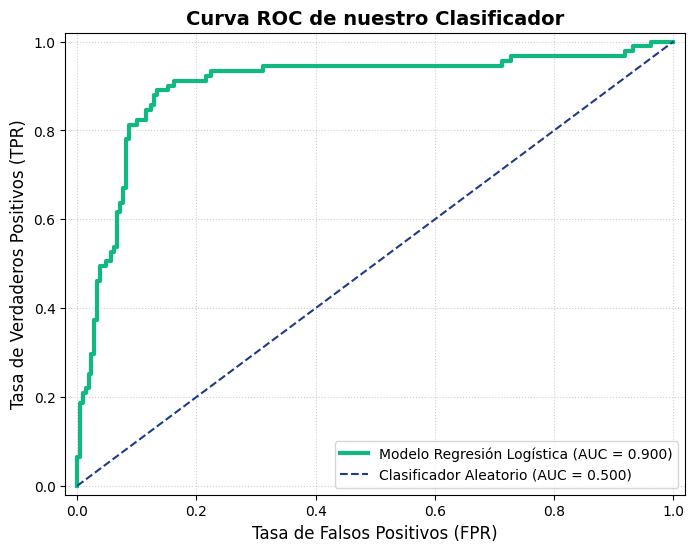

Gráfico generado correctamente.



In [4]:
# =============================================================================
# EJERCICIO 3: Cálculo y Visualización de la Curva ROC y AUC
# =============================================================================
print("=" * 70)
print("EJERCICIO 3: Cálculo y Visualización de la Curva ROC y AUC")
print("=" * 70)

# Utilizando las probabilidades continuas 'y_probs' calculadas en el paso anterior:

# 1. Calcula la puntuación del AUC global
auc_score = roc_auc_score(y_test, y_probs)

# 2. Obtén los vectores FPR, TPR y thresholds de la curva usando roc_curve
fpr_vector, tpr_vector, umbrales = roc_curve(y_test, y_probs)

print(f"El AUC global obtenido para este clasificador es: {auc_score:.4f}")
print("Generando gráfico de la curva ROC...")

# 3. Graficamos la curva ROC
plt.figure(figsize=(8, 6))

# Dibujamos la curva del modelo (Verde esmeralda de la presentación v2)
plt.plot(
    fpr_vector,
    tpr_vector,
    color='#10b981',
    lw=3,
    label=f"Modelo Regresión Logística (AUC = {auc_score:.3f})"
)

# Dibujamos la línea diagonal de referencia (Azar - Azul profundo)
plt.plot(
    [0, 1],
    [0, 1],
    color='#1e3a8a',
    linestyle='--',
    lw=1.5,
    label="Clasificador Aleatorio (AUC = 0.500)"
)

# Personalización del gráfico para que luzca profesional
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
plt.title('Curva ROC de nuestro Clasificador', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()
print("Gráfico generado correctamente.\n")




In [5]:
# =============================================================================
# EJERCICIO 4: Selección del Umbral Óptimo (Índice de Youden)
# =============================================================================
print("=" * 70)
print("EJERCICIO 4: Selección del Umbral Óptimo (Índice de Youden)")
print("=" * 70)

# Buscaremos el umbral teórico que maximiza la distancia vertical al azar:
# Fórmula: J = TPR - FPR

# 1. Calcula el Índice de Youden para cada punto calculado en la curva ROC
indice_youden = tpr_vector - fpr_vector

# 2. Encuentra la posición del índice con el valor máximo
posicion_optima = np.argmax(indice_youden)

# Extraemos el valor del umbral correspondiente a esa posición óptima
umbral_optimo = umbrales[posicion_optima]

print(f"El umbral óptimo teórico según el Índice de Youden es: {umbral_optimo:.4f}")
print(f"A este umbral, el modelo obtiene:")
print(f"   - Sensibilidad (TPR): {tpr_vector[posicion_optima]:.3f}")
print(f"   - Falsa Alarma (FPR): {fpr_vector[posicion_optima]:.3f}")
print("=" * 70)

EJERCICIO 4: Selección del Umbral Óptimo (Índice de Youden)
El umbral óptimo teórico según el Índice de Youden es: 0.1937
A este umbral, el modelo obtiene:
   - Sensibilidad (TPR): 0.890
   - Falsa Alarma (FPR): 0.134
